In [1]:
import matplotlib.pyplot as plt
from msca import *
import os
import importlib
import msca
import msca.models
import msca.architectures
import msca.utils
import msca.simulations
import msca.evaluations
from msca.evaluations import evaluate_trial_average
# Suppress MallocStackLogging warnings on macOS
os.environ["MallocStackLogging"] = "0"

# Reload msca and key submodules after code changes
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
importlib.reload(msca.simulations)
importlib.reload(msca.evaluations)

# Re-import updated symbols
from msca import *




In [2]:
import scipy.io as sio
mat = sio.loadmat("./data/Cousteau_interp_cycling_m1_rawRates.mat")
mask = mat["mask"]


In [3]:
import importlib
import os
import numpy as np
from scipy import io


def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path + f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    return data_array, mask, start_idxs, end_idxs


# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data



fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


## Load Saved Neuron Split Indices




In [4]:
# nonlinear nonlinear : all split are identical 
experiment_path = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5/"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")


Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]


# Sanity_check for the evaluation function 
- use the new evaluation function : evaluate_trial_average(
    msca, X_train, X_val, regressor, n_splits=5, threshold=0.0001
)
- get the bootstrap for n_compoennts=10 for nonlinear & linear model 
- check if nonlienar one out perform the linear one 



In [11]:
# Test all three model types for n_components=10
from sklearn.metrics import r2_score

n_components = 40
n_folds = 1

experiment_configs = {
    "linear-linear": {
        "root": "./results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5",
        "linear": True,
        "decoder_type": "linear",
        "decoder_hidden_size": n_components,
    },
    "nonlinear-linear": {
        "root": "./results/bi-cross-validation-Cousteau-nonlinear-linear-lamsparse-2.5",
        "linear": False,
        "decoder_type": "linear",
        "decoder_hidden_size": n_components,
    },
    "nonlinear-nonlinear": {
        "root": "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5",
        "linear": False,
        "decoder_type": "nonlinear",
        "decoder_hidden_size": n_components,
    },
}

def _align_trial(pred_trial, actual_trial, trunc):
    pred = np.asarray(pred_trial)
    true = np.asarray(actual_trial)[trunc]
    t = min(pred.shape[0], true.shape[0])
    n = min(pred.shape[1], true.shape[1])
    return pred[:t, :n], true[:t, :n]

def compute_r2_from_predictions(predictions, X_val, trunc, n_boot=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    r2_region = {}

    for region in X_val.keys():
        y_true_trials = []
        y_pred_trials = []

        for pred_trial, actual_trial in zip(predictions[region], X_val[region]):
            pred_t, true_t = _align_trial(pred_trial, actual_trial, trunc)
            y_pred_trials.append(pred_t)
            y_true_trials.append(true_t)

        y_true = np.concatenate(y_true_trials, axis=0)
        y_pred = np.concatenate(y_pred_trials, axis=0)

        n_neurons = y_true.shape[1]
        boot_r2 = []
        for _ in range(n_boot):
            neuron_idx = rng.integers(0, n_neurons, size=n_neurons)
            boot_r2.append(
                r2_score(
                    y_true[:, neuron_idx],
                    y_pred[:, neuron_idx],
                    multioutput="uniform_average",
                )
            )

        r2_region[region] = {
            "mean": float(np.mean(boot_r2)),
            "std": float(np.std(boot_r2)),
            "samples": np.asarray(boot_r2),
        }

    return r2_region

# Store per-fold metrics: {model_name: {fold: {region_r2}}}
results_by_fold = {name: {} for name in experiment_configs.keys()}

for model_name, config in experiment_configs.items():
    print(f"\n{'='*80}")
    print(f"Testing: {model_name.upper()}")
    print(f"{'='*80}")

    exp_root = config["root"]

    for fold in range(n_folds):
        print(f"\n  Fold {fold}:")

        model_fp = f"{exp_root}/n_components_{n_components}/msca_split_{fold}.pt"
        train_split_path = f"{exp_root}/n_train_splits.pt"
        test_split_path = f"{exp_root}/n_test_splits.pt"

        train_idxs = torch.load(train_split_path, weights_only=False)
        test_idxs = torch.load(test_split_path, weights_only=False)

        X_train = {k: [trial[:, train_idxs[k][fold]] for trial in v] for k, v in X.items()}
        X_val = {k: [trial[:, test_idxs[k][fold]] for trial in v] for k, v in X.items()}

        msca = mSCA(
            n_components=n_components,
            n_epochs=5000,
            loss_func="Gaussian",
            lr=1e-3,
            filter_len=41,
            linear=config["linear"],
            region_weights=None,
            lam_sparse=2.5,
            lam_orthog=0,
            lam_region=None,
            batch_size=64,
            cd_rate=0.5,
            decoder_type=config["decoder_type"],
            decoder_hidden_size=config["decoder_hidden_size"],
            decoder_activation="GeLU",
            device="cpu",
            cd_mode="both",
            post_hoc_epoch=-1,
        )

        msca.load(model_fp, X_train)
        predictions = evaluate_trial_average(msca, X_train, X_val, "mlp", n_splits=5)

        region_r2 = compute_r2_from_predictions(
            predictions, X_val, trunc=msca.trunc, n_boot=1000, random_state=0
        )

        results_by_fold[model_name][fold] = {
            "region_r2": region_r2,
        }

        region_text = ", ".join(
            [f"{r}={region_r2[r]['mean']:.4f}" for r in sorted(region_r2.keys())]
        )
        print(f"    region R² bootstrap mean: {region_text}")

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")

for model_name in experiment_configs.keys():
    if len(results_by_fold[model_name]) == 0:
        print(f"\n{model_name}: no results")
        continue

    fold_metrics = [
        results_by_fold[model_name][f]
        for f in sorted(results_by_fold[model_name].keys())
    ]
    print(f"\n{model_name}")

    regions = sorted(fold_metrics[0]["region_r2"].keys())
    for region in regions:
        region_vals = np.array(
            [m["region_r2"][region]["mean"] for m in fold_metrics], dtype=float
        )
        print(f"  {region} R² bootstrap: {np.nanmean(region_vals):.4f} ± {np.nanstd(region_vals):.4f}")


Testing: LINEAR-LINEAR

  Fold 0:


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


FileNotFoundError: [Errno 2] No such file or directory: './results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5/n_components_40/msca_split_0.pt'

# Check Parameters for three types of model (n_component=10)

metadata:
  lam_sparse: 0.511919926930158
  lam_orthog: 0.0
  lam_region: 0.0
  region_weights: {'M1': 0.7868798060360273, 'SMA': 1.371445095611241}
  n_components: 10
  linear: False
  decoder_type: nonlinear
  decoder_hidden_size: 10
  decoder_activation: GeLU


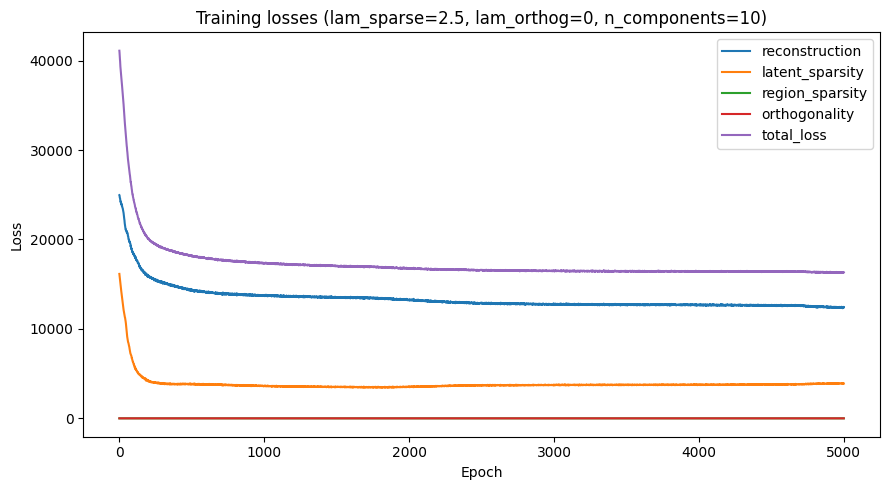

In [13]:
import torch
n_components=10

# ========================================= Linear Encoder + Linear Decoder =========================================
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5"
fold = 0

model_fp = f"{experiment_root}/n_components_10/msca_split_{fold}.pt"
loss_fp = f"{experiment_root}/n_components_10/losses_split_{fold}.pt"
train_split_path = f"{experiment_root}/n_train_splits.pt"

# Print checkpoint information from model_fp
checkpoint = torch.load(model_fp, map_location="cpu")
if isinstance(checkpoint, dict):
    # print("checkpoint keys:", list(checkpoint.keys()))
    if "meta" in checkpoint and isinstance(checkpoint["meta"], dict):
        print("metadata:")
        for k, v in checkpoint["meta"].items():
            print(f"  {k}: {v}")

# Load the same neuron split used to train this checkpoint
train_idxs = torch.load(train_split_path, weights_only=False)
X_train_split = {
    region: [trial[:, train_idxs[region][fold]] for trial in trials]
    for region, trials in X.items()
}

# Build model with settings matching the saved checkpoint family
msca = mSCA(
    n_components=n_components,
    n_epochs=5000,
    loss_func="Gaussian",
    lr=1e-3,
    filter_len=21,
    linear=False,
    region_weights=None,
    lam_sparse=2.5,
    lam_orthog=0,
    lam_region=None,
    batch_size=64,
    cd_rate=0.5,
    decoder_type="nonlinear",
    decoder_hidden_size=n_components,
    decoder_activation="GeLU",
    device="cpu",
    cd_mode="both",
    post_hoc_epoch=-1,
 )

# Important: load with split-matched data to set correct input/output dimensions
msca.load(model_fp, X_train_split)

# Support both legacy .npz and current .pt loss formats
if loss_fp.endswith(".npz"):
    losses = mSCA.load_losses(loss_fp)
else:
    losses = torch.load(loss_fp, map_location="cpu")

plt.figure(figsize=(9, 5))
n_plotted = 0
for name, vals in losses.items():
    name_str = name.decode("utf-8", errors="replace") if isinstance(name, bytes) else str(name)
    vals_np = np.asarray(vals)
    if not np.issubdtype(vals_np.dtype, np.number):
        continue
    vals_np = np.ravel(vals_np.astype(float))
    if vals_np.size == 0:
        continue
    plt.plot(vals_np, label=name_str)
    n_plotted += 1

if n_plotted == 0:
    print("No numeric loss curves found in the loaded loss file.")
else:
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training losses (lam_sparse=2.5, lam_orthog=0, n_components=10)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# ...existing code...
if loss_fp.endswith(".npz"):
    losses = mSCA.load_losses(loss_fp)
else:
    losses = torch.load(loss_fp, map_location="cpu")

# Print final reconstruction loss
recon_key = None
preferred = ["reconstruction", "recon_loss", "loss_reconstruction"]
for k in losses.keys():
    ks = k.decode("utf-8", errors="replace") if isinstance(k, bytes) else str(k)
    if ks in preferred:
        recon_key = k
        break
if recon_key is None:
    for k in losses.keys():
        ks = k.decode("utf-8", errors="replace") if isinstance(k, bytes) else str(k)
        if ("recon" in ks.lower()) and ("loss" in ks.lower()):
            recon_key = k
            break

if recon_key is None:
    print("No reconstruction loss key found in loss file.")
else:
    vals = np.asarray(losses[recon_key], dtype=float).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print("Reconstruction loss exists but has no numeric values.")
    else:
        print(f"Final reconstruction loss ({recon_key}): {vals[-1]:.6f}")
# ...existing code...

Final reconstruction loss (reconstruction): 12438.548828
